# 서울 지하철 혼잡도 분석 — SCQA Framework

**이어드림 팀 프로젝트** | 분석일: 2026-06-25

## 사용 데이터
| 파일 | 내용 | 행수 |
|---|---|---:|
| `서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv` | 역별·시간대별 승하차 인원 (201501~202605) | 82,352행 |
| `서울교통공사_지하철혼잡도정보_20260331.csv` | 열차 내 실제 혼잡도 (%) | 1,671행 |
| `CARD_SUBWAY_MONTH_202605.csv` | 2026년 5월 카드 승하차 일별 | 19,131행 |

## 분석 핵심
두 데이터프레임(승하차 인원 + 혼잡도)을 **호선 + 역명** 기준으로 JOIN하여
'사람이 많은 역' vs '열차가 실제로 붐비는 구간'의 차이를 도출합니다.

In [2]:
# ── 0. 라이브러리 및 경로 설정 ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 경로는 현재 작업폴더(노트북 위치 = team_project) 기준으로 자동 산출
import os
BASE = os.getcwd()
DATA = os.path.join(BASE, '/content/')

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 데이터 로드

In [3]:
# ── 1-1. 시간대별 승하차 인원 (메인 데이터) ─────────────────────────
df_ride = pd.read_csv(
    f'{DATA}/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv',
    encoding='cp949'
)
print(f'승하차 데이터: {df_ride.shape[0]:,}행 × {df_ride.shape[1]}열')
print(f'기간: {df_ride["사용월"].min()} ~ {df_ride["사용월"].max()}')
df_ride.head(3)

승하차 데이터: 82,352행 × 52열
기간: 201501 ~ 202605


,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202605,1호선,동대문,715,21,10855,2123,9369,7719,15679,...,10982,875,3171,0,264,2,0,0,0,20260603
1,202605,1호선,동묘앞,161,3,2920,1105,4082,6397,8524,...,5199,125,2420,0,314,0,0,0,0,20260603
2,202605,1호선,서울역,802,57,12246,11962,37333,70445,107361,...,40460,5016,9678,16,207,0,0,0,0,20260603


In [ ]:
# ── 1-2. 혼잡도 데이터 ──────────────────────────────────────────────
df_cong = pd.read_csv(
    f'{DATA}/서울교통공사_지하철혼잡도정보_20260331.csv',
    encoding='cp949'
)
print(f'혼잡도 데이터: {df_cong.shape[0]:,}행 × {df_cong.shape[1]}열')
print(f'컬럼: {df_cong.columns.tolist()[:8]} ...')
df_cong.head(3)

혼잡도 데이터: 1,671행 × 44열
컬럼: ['요일구분', '호선', '역번호', '출발역', '상하구분', '5시30분', '6시00분', '6시30분'] ...


,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,평일,1호선,150,서울역,상선,8.0,20.7,23.2,41.2,67.7,...,20.5,18.6,20.0,15.0,16.5,16.8,14.0,9.2,5.9,1.3
1,평일,1호선,150,서울역,하선,11.2,11.1,17.7,24.8,41.7,...,41.0,40.4,43.3,38.0,39.5,30.2,18.7,12.8,8.6,0.0
2,평일,1호선,151,시청,상선,6.7,14.8,18.8,32.7,51.8,...,24.9,22.7,24.6,18.5,20.6,20.4,17.2,10.6,6.6,1.3


In [ ]:
# ── 1-3. 카드 승하차 2026-05 (참고용 — 본 분석에는 사용하지 않음) ──
# CARD_SUBWAY_MONTH_202605.csv 는 승하차/혼잡도 분석과 중복 지표라 로드하지 않는다.
# 필요 시 아래 주석을 해제해 탐색용으로만 사용.
# df_card = pd.read_csv(os.path.join(DATA, 'CARD_SUBWAY_MONTH_202605.csv'), encoding='utf-8-sig')
# df_card.columns = ['USE_YMD','노선명','역명','승차','하차','등록일자']
print('카드 데이터: 본 분석 미사용 (스킵)')

카드 데이터: 본 분석 미사용 (스킵)


---
## 2. 데이터 전처리 및 DataFrame JOIN

### JOIN 전략
- 승하차 인원: `호선명` + `지하철역` → 월별 시간대별 수요
- 혼잡도: `호선` + `출발역` → 실제 열차 내 혼잡률(%)
- **JOIN KEY**: 호선명 정규화 후 역명 매칭

In [ ]:
# ── 2-1. 2026-05 승하차 데이터 추출 ─────────────────────────────────
df_ride_2605 = df_ride[df_ride['사용월'] == 202605].copy()

# 승차·하차 컬럼 합산 → 역별 총 이용량
on_cols  = [c for c in df_ride_2605.columns if '승차인원' in c]
off_cols = [c for c in df_ride_2605.columns if '하차인원' in c]

# 피크 시간대 컬럼 (출근·퇴근)
peak_on_morn  = '08시-09시 승차인원'
peak_off_morn = '08시-09시 하차인원'
peak_on_eve   = '18시-19시 승차인원'
peak_off_eve  = '18시-19시 하차인원'

df_ride_2605['총이용_월'] = df_ride_2605[on_cols].sum(axis=1) + df_ride_2605[off_cols].sum(axis=1)
df_ride_2605['피크_출근'] = df_ride_2605[peak_on_morn] + df_ride_2605[peak_off_morn]
df_ride_2605['피크_퇴근'] = df_ride_2605[peak_on_eve]  + df_ride_2605[peak_off_eve]

# 역별 집계
ride_agg = df_ride_2605.groupby(['호선명', '지하철역']).agg(
    총이용_월=('총이용_월', 'sum'),
    피크_출근=('피크_출근', 'sum'),
    피크_퇴근=('피크_퇴근', 'sum')
).reset_index()

print(f'승하차 집계: {len(ride_agg)}역')
ride_agg.head()

승하차 집계: 620역


,호선명,지하철역,총이용_월,피크_출근,피크_퇴근
0,1호선,동대문,938660,45044,61226
1,1호선,동묘앞,808891,37020,43639
2,1호선,서울역,4855066,424211,462771
3,1호선,시청,1573744,202385,179308
4,1호선,신설동,870069,83008,84225


In [ ]:
# ── 2-2. 혼잡도 전처리 ──────────────────────────────────────────────
# 러시아워 혼잡도 평균 (출근 7:30~9:00, 퇴근 18:00~19:00)
rush_cols_morn = ['7시30분', '8시00분', '8시30분']
rush_cols_eve  = ['18시00분', '18시30분']

rush_exist_morn = [c for c in rush_cols_morn if c in df_cong.columns]
rush_exist_eve  = [c for c in rush_cols_eve  if c in df_cong.columns]

df_cong['혼잡_출근평균'] = df_cong[rush_exist_morn].mean(axis=1)
df_cong['혼잡_퇴근평균'] = df_cong[rush_exist_eve].mean(axis=1)
df_cong['혼잡_러시평균'] = df_cong[rush_exist_morn + rush_exist_eve].mean(axis=1)
# 혼잡_최대 = '러시아워(출근+퇴근) 구간 중 최대' (전일 24시간 최대가 아님)
# 주의: 혼잡도 자료는 서울교통공사 1~8호선만 제공 → 9호선·경의중앙 등은 JOIN 미매칭(자료 한계)
df_cong['혼잡_최대']     = df_cong[rush_exist_morn + rush_exist_eve].max(axis=1)

# 평일만
cong_weekday = df_cong[df_cong['요일구분'] == '평일'].copy()

# 역별 최대 혼잡도
cong_agg = cong_weekday.groupby(['호선', '출발역']).agg(
    혼잡_출근평균=('혼잡_출근평균', 'max'),
    혼잡_퇴근평균=('혼잡_퇴근평균', 'max'),
    혼잡_최대=('혼잡_최대', 'max')
).reset_index()

print(f'혼잡도 집계: {len(cong_agg)}역-방향')
cong_agg.sort_values('혼잡_최대', ascending=False).head(10)

혼잡도 집계: 281역-방향


,호선,출발역,혼잡_출근평균,혼잡_퇴근평균,혼잡_최대
26,2호선,사당,137.233333,123.45,147.7
257,7호선,철산,138.766667,118.30,147.6
268,8호선,몽촌토성,142.700000,127.15,146.5
263,8호선,강동구청,140.033333,121.65,145.3
226,7호선,군자,137.033333,131.90,144.2
254,7호선,중곡,134.333333,129.10,143.9
24,2호선,방배,132.233333,137.65,143.9
220,7호선,가산디지털단지,99.433333,131.70,143.9
246,7호선,어린이대공원,134.266667,131.70,143.3
248,7호선,용마산,128.766667,127.65,141.6


In [ ]:
# ── 2-3. 호선명 정규화 → JOIN ────────────────────────────────────────
# 혼잡도의 '호선' 컬럼: '1호선', '2호선' 등 (승하차의 '호선명'과 동일 포맷 확인)
print('승하차 호선명 샘플:', ride_agg['호선명'].unique()[:8])
print('혼잡도 호선 샘플: ', cong_agg['호선'].unique()[:8])

# 컬럼명 통일
cong_agg_renamed = cong_agg.rename(columns={
    '호선': '호선명',
    '출발역': '지하철역'
})

# LEFT JOIN: 승하차 기준으로 혼잡도 결합
df_joined = ride_agg.merge(
    cong_agg_renamed,
    on=['호선명', '지하철역'],
    how='left'
)

matched = df_joined['혼잡_최대'].notna().sum()
print(f'\nJOIN 결과: {len(df_joined)}행 | 혼잡도 매칭: {matched}역 ({matched/len(df_joined)*100:.1f}%)')
df_joined.head()

승하차 호선명 샘플: <StringArray>
['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선']
Length: 8, dtype: str
혼잡도 호선 샘플:  <StringArray>
['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선']
Length: 8, dtype: str

JOIN 결과: 620행 | 혼잡도 매칭: 211역 (34.0%)


,호선명,지하철역,총이용_월,피크_출근,피크_퇴근,혼잡_출근평균,혼잡_퇴근평균,혼잡_최대
0,1호선,동대문,938660,45044,61226,79.166667,86.40,89.4
1,1호선,동묘앞,808891,37020,43639,78.066667,78.45,87.0
2,1호선,서울역,4855066,424211,462771,80.233333,99.70,126.9
3,1호선,시청,1573744,202385,179308,57.966667,95.40,113.6
4,1호선,신설동,870069,83008,84225,71.066667,75.45,77.3


> **JOIN 포인트**: 역명 표기 차이(괄호 포함 여부 등)로 매칭률이 100%가 아닐 수 있습니다.  
> 미매칭 역은 아래에서 확인 후 필요시 역명 정규화 처리합니다.

In [ ]:
# ── 2-4. 미매칭 역 확인 및 역명 정규화 ──────────────────────────────
unmatched = df_joined[df_joined['혼잡_최대'].isna()]
print(f'미매칭 역 수: {len(unmatched)}')

# 혼잡도 데이터에 있는 역 목록 (정규화 비교용)
cong_stations = set(cong_agg_renamed['지하철역'].unique())
ride_stations = set(ride_agg['지하철역'].unique())

only_in_cong = cong_stations - ride_stations
only_in_ride = ride_stations - cong_stations

print(f'혼잡도에만 있는 역: {len(only_in_cong)}개 (샘플: {list(only_in_cong)[:10]})')
print(f'승하차에만 있는 역: {len(only_in_ride)}개 (샘플: {list(only_in_ride)[:10]})')

미매칭 역 수: 409
혼잡도에만 있는 역: 59개 (샘플: ['숭실대입구', '대흥', '상월곡', '남한산성입구', '온수', '녹사평', '이촌', '잠실', '응암S', '총신대입구'])
승하차에만 있는 역: 342개 (샘플: ['두정', '숭의', '지평', '인하대', '천호(풍납토성)', '중앙', '솔샘', '원종', '청산', '양정'])


In [ ]:
# ── 2-5. 역명 정규화 함수 (괄호 제거, 공백 제거) ─────────────────────
import re

def normalize_station(name):
    """역명 정규화: 괄호 안 부가 설명 제거, 공백 제거"""
    if pd.isna(name): return name
    name = str(name).strip()
    name = re.sub(r'\(.*?\)', '', name).strip()  # 괄호 제거
    return name

# 정규화 컬럼 추가
ride_agg['역명_정규화'] = ride_agg['지하철역'].apply(normalize_station)
cong_agg_renamed['역명_정규화'] = cong_agg_renamed['지하철역'].apply(normalize_station)

# 정규화 기준 재 JOIN
df_joined2 = ride_agg.merge(
    cong_agg_renamed[['호선명', '역명_정규화', '혼잡_출근평균', '혼잡_퇴근평균', '혼잡_최대']],
    on=['호선명', '역명_정규화'],
    how='left'
)

matched2 = df_joined2['혼잡_최대'].notna().sum()
print(f'정규화 후 매칭: {matched2}역 ({matched2/len(df_joined2)*100:.1f}%)')
_lines18 = ['1호선','2호선','3호선','4호선','5호선','6호선','7호선','8호선']
_inscope = df_joined2['호선명'].isin(_lines18).sum()
_match_in = df_joined2[df_joined2['호선명'].isin(_lines18)]['혼잡_최대'].notna().sum()
print(f'  └ 혼잡도 제공(1~8호선) {_inscope}역 한정 매칭: {_match_in}역 '
      f'({_match_in/_inscope*100:.1f}%)  ※ 나머지는 혼잡도 미제공 노선')
df_joined2.head()

정규화 후 매칭: 278역 (44.7%)
  └ 혼잡도 제공(1~8호선) 278역 한정 매칭: 278역 (100.0%)  ※ 나머지는 혼잡도 미제공 노선


,호선명,지하철역,총이용_월,피크_출근,피크_퇴근,역명_정규화,혼잡_출근평균,혼잡_퇴근평균,혼잡_최대
0,1호선,동대문,938660,45044,61226,동대문,79.166667,86.40,89.4
1,1호선,동묘앞,808891,37020,43639,동묘앞,78.066667,78.45,87.0
2,1호선,서울역,4855066,424211,462771,서울역,80.233333,99.70,126.9
3,1호선,시청,1573744,202385,179308,시청,57.966667,95.40,113.6
4,1호선,신설동,870069,83008,84225,신설동,71.066667,75.45,77.3


---
## 3. SCQA 분석

### S — Situation: 현재 이용 현황

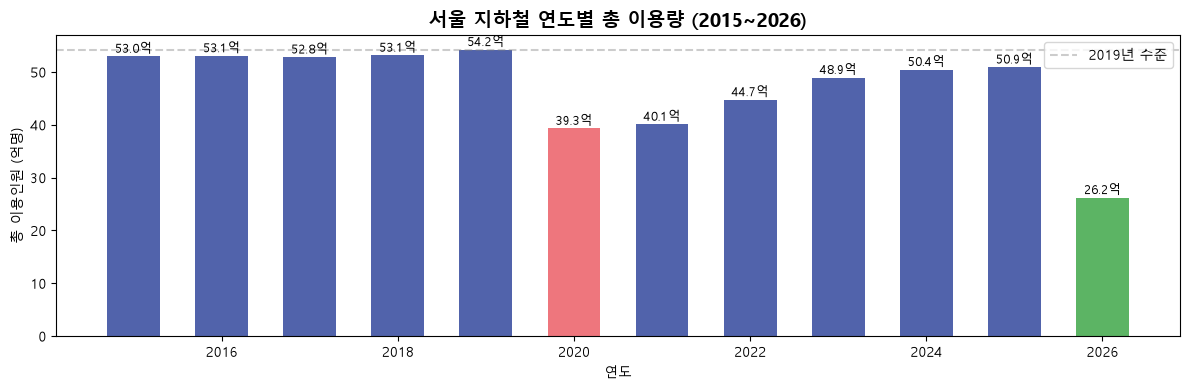

In [ ]:
# ── 3-S-1. 연도별 이용량 추이 ────────────────────────────────────────
df_ride['연도'] = (df_ride['사용월'] // 100).astype(int)
on_cols_all  = [c for c in df_ride.columns if '승차인원' in c]
off_cols_all = [c for c in df_ride.columns if '하차인원' in c]
df_ride['월총이용'] = df_ride[on_cols_all].sum(axis=1) + df_ride[off_cols_all].sum(axis=1)

yearly = df_ride.groupby('연도')['월총이용'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#EA545D' if y == 2020 else '#33A23D' if y == 2026 else '#263C96'
          for y in yearly['연도']]
bars = ax.bar(yearly['연도'], yearly['월총이용'] / 1e8, color=colors, alpha=0.8, width=0.6)

for bar, val in zip(bars, yearly['월총이용']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val/1e8:.1f}억', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('연도'); ax.set_ylabel('총 이용인원 (억명)')
ax.set_title('서울 지하철 연도별 총 이용량 (2015~2026)', fontsize=14, fontweight='bold')
ax.axhline(y=54.22, color='gray', linestyle='--', alpha=0.4, label='2019년 수준')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_yearly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

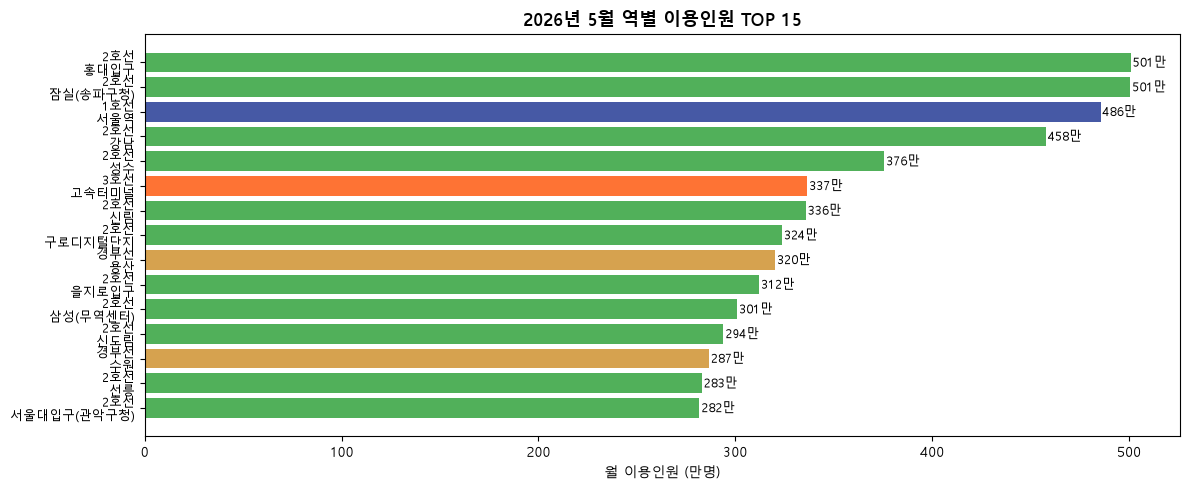

In [ ]:
# ── 3-S-2. 2026-05 역별 이용 TOP 15 ─────────────────────────────────
top15 = df_joined2.nlargest(15, '총이용_월')[['호선명', '지하철역', '총이용_월', '피크_출근', '피크_퇴근']]
top15['총이용_월_만'] = (top15['총이용_월'] / 10000).round(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{row['호선명']}\n{row['지하철역']}" for _, row in top15.iterrows()]
colors_line = {
    '1호선':'#263C96','2호선':'#33A23D','3호선':'#FE5B10',
    '4호선':'#00A5DE','5호선':'#996CAC','7호선':'#747F00',
    '8호선':'#EA545D','경부선':'#CF9230'
}
bar_colors = [colors_line.get(row['호선명'], '#888') for _, row in top15.iterrows()]

bars = ax.barh(range(len(top15)), top15['총이용_월'] / 1e4, color=bar_colors, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('월 이용인원 (만명)')
ax.set_title('2026년 5월 역별 이용인원 TOP 15', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top15['총이용_월']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val/10000:.0f}만', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_top15_station.png'), dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ── 3-S-3. 시간대별 이용량 ────────────────────────────────────────────
hour_sum_on  = df_ride_2605[on_cols].sum()
hour_sum_off = df_ride_2605[off_cols].sum()
hour_total   = hour_sum_on.values + hour_sum_off.values
hours_label  = [c.replace(' 승차인원','') for c in on_cols]

hour_df = pd.DataFrame({'시간대': hours_label, '이용인원': hour_total})

fig, ax = plt.subplots(figsize=(14, 4))
peak_indices = [i for i, h in enumerate(hours_label) if h.startswith('08시') or h.startswith('18시')]
bar_c = ['#EA545D' if i in peak_indices else '#263C96' for i in range(len(hours_label))]
ax.bar(range(len(hours_label)), hour_total / 1e6, color=bar_c, alpha=0.8)
ax.set_xticks(range(len(hours_label)))
ax.set_xticklabels([h.replace('시-','~') for h in hours_label], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('이용인원 (백만명)')
ax.set_title('2026년 5월 시간대별 총 이용인원', fontsize=13, fontweight='bold')
ax.annotate('퇴근피크\n18-19시', xy=(14, hour_total[14]/1e6), xytext=(13, hour_total[14]/1e6+2),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10, fontweight='bold')
ax.annotate('출근피크\n08-09시', xy=(4, hour_total[4]/1e6), xytext=(3, hour_total[4]/1e6+2),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_hourly.png'), dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'df_ride_2605' is not defined

---
### C — Complication: 문제의 본질

**이용량이 많은 역 ≠ 열차가 가장 붐비는 구간**

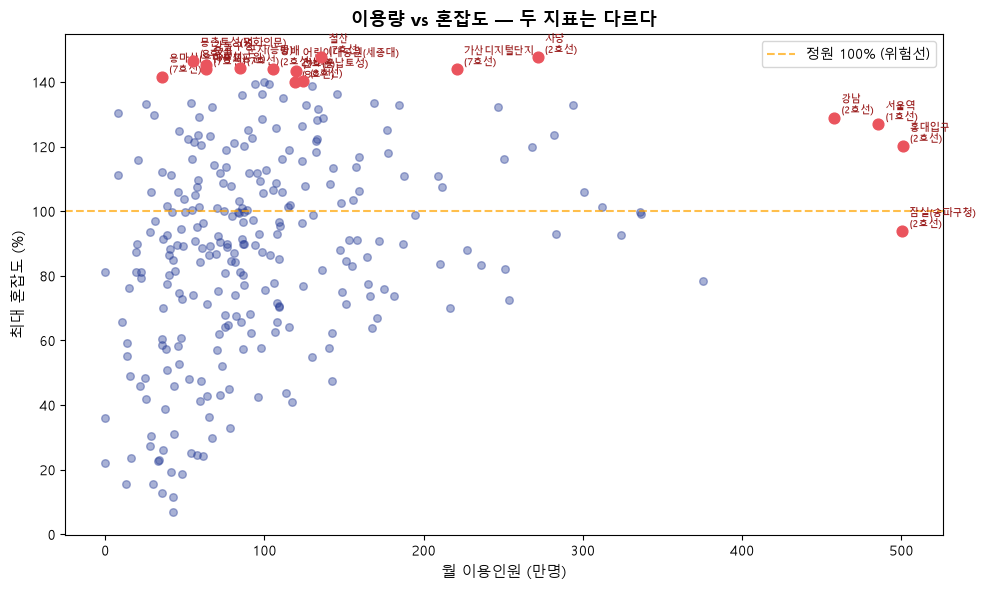


혼잡도 100% 초과 역: 109개
혼잡도 140% 초과 역: 12개


In [ ]:
# ── 3-C-1. JOIN 데이터: 이용량 vs 혼잡도 산점도 ─────────────────────
df_plot = df_joined2.dropna(subset=['혼잡_최대']).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    df_plot['총이용_월'] / 1e4,
    df_plot['혼잡_최대'],
    alpha=0.4, s=30, color='#263C96'
)

# 특이값 강조 (혼잡도 높거나 이용량 높은 역)
highlight = df_plot[
    (df_plot['혼잡_최대'] >= 140) | (df_plot['총이용_월'] >= 4_000_000)
]
ax.scatter(highlight['총이용_월']/1e4, highlight['혼잡_최대'],
           color='#EA545D', s=60, zorder=5)
for _, row in highlight.iterrows():
    ax.annotate(f"{row['지하철역']}\n({row['호선명']})",
                xy=(row['총이용_월']/1e4, row['혼잡_최대']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=7, color='#991B1B')

ax.axhline(y=100, color='orange', linestyle='--', alpha=0.7, label='정원 100% (위험선)')
ax.set_xlabel('월 이용인원 (만명)', fontsize=11)
ax.set_ylabel('최대 혼잡도 (%)', fontsize=11)
ax.set_title('이용량 vs 혼잡도 — 두 지표는 다르다', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_scatter_ride_vs_cong.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n혼잡도 100% 초과 역: {(df_plot["혼잡_최대"] >= 100).sum()}개')
print(f'혼잡도 140% 초과 역: {(df_plot["혼잡_최대"] >= 140).sum()}개')

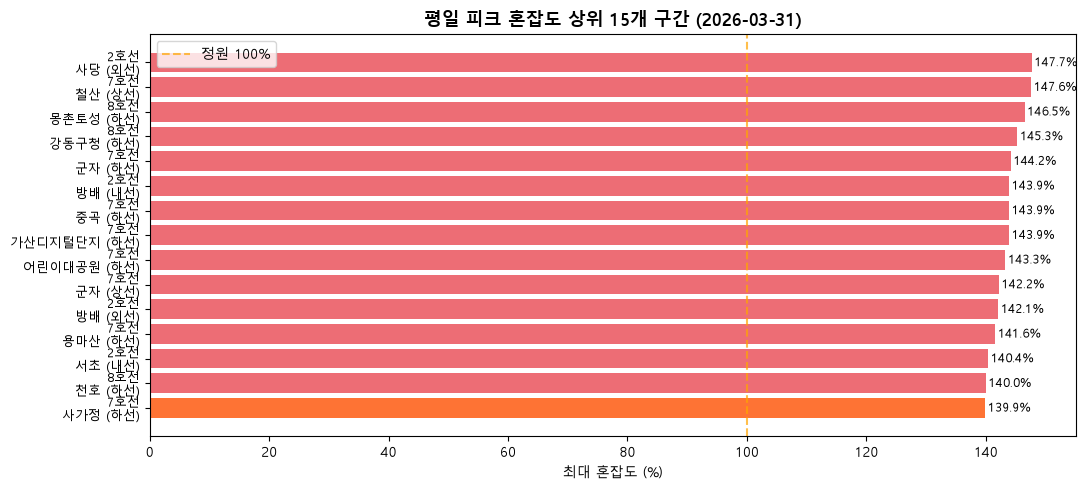

In [ ]:
# ── 3-C-2. 혼잡도 상위 구간 (평일 피크 기준) ─────────────────────────
top_cong = cong_weekday.nlargest(15, '혼잡_최대')[['호선','출발역','상하구분','혼잡_출근평균','혼잡_퇴근평균','혼잡_최대']]

fig, ax = plt.subplots(figsize=(11, 5))
labels2 = [f"{row['호선']}\n{row['출발역']} ({row['상하구분']})" for _, row in top_cong.iterrows()]
colors2 = ['#EA545D' if v >= 140 else '#FE5B10' if v >= 120 else '#263C96'
           for v in top_cong['혼잡_최대']]
bars2 = ax.barh(range(len(top_cong)), top_cong['혼잡_최대'], color=colors2, alpha=0.85)
ax.set_yticks(range(len(top_cong)))
ax.set_yticklabels(labels2, fontsize=9)
ax.set_xlabel('최대 혼잡도 (%)')
ax.set_title('평일 피크 혼잡도 상위 15개 구간 (2026-03-31)', fontsize=13, fontweight='bold')
ax.axvline(x=100, color='orange', linestyle='--', alpha=0.7, label='정원 100%')
ax.invert_yaxis()
for bar, val in zip(bars2, top_cong['혼잡_최대']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_top_congestion.png'), dpi=150, bbox_inches='tight')
plt.show()

---
### Q → A: 핵심 질문과 답 — JOIN 결과 기반 우선순위

In [ ]:
# ── 3-QA. JOIN 결과: 이용량 + 혼잡도 종합 순위 ──────────────────────
# 혼잡도 있는 역만
df_priority = df_joined2.dropna(subset=['혼잡_최대']).copy()

# 종합 점수: 혼잡도(%) 70% + 피크이용량 30% (정규화)
def minmax_norm(_s):
    # 모든 값이 같으면 분모 0 → 0 처리(크래시·inf 방지)
    _rng = _s.max() - _s.min()
    if _rng == 0 or pd.isna(_rng):
        return pd.Series(0.0, index=_s.index)
    return (_s - _s.min()) / _rng

df_priority['혼잡_norm']  = minmax_norm(df_priority['혼잡_최대'])
peak_col = df_priority[['피크_출근','피크_퇴근']].max(axis=1)
df_priority['피크_norm']  = minmax_norm(peak_col)
df_priority['종합점수']    = df_priority['혼잡_norm'] * 0.7 + df_priority['피크_norm'] * 0.3

top10_priority = df_priority.nlargest(10, '종합점수')[
    ['호선명','지하철역','혼잡_최대','피크_출근','피크_퇴근','종합점수']
].reset_index(drop=True)
top10_priority.index += 1

print('★ 혼잡도 + 이용량 종합 우선순위 TOP 10 ★')
print(top10_priority.to_string())

★ 혼잡도 + 이용량 종합 우선순위 TOP 10 ★
    호선명     지하철역  혼잡_최대   피크_출근   피크_퇴근      종합점수
1   7호선  가산디지털단지  143.9  366249  302767  0.910957
2   2호선       강남  129.0  360628  472309  0.903441
3   1호선      서울역  126.9  424211  462771  0.887015
4   2호선       사당  147.7  174825  280088  0.875776
5   2호선     홍대입구  120.2  187560  461405  0.852848
6   2호선      신도림  132.8  239050  277553  0.800109
7   7호선       철산  147.6  125232  128124  0.779910
8   2호선       역삼  119.8  335402  292322  0.771783
9   4호선       혜화  132.4  138602  216516  0.759814
10  2호선       서초  140.4  135003  114800  0.748432


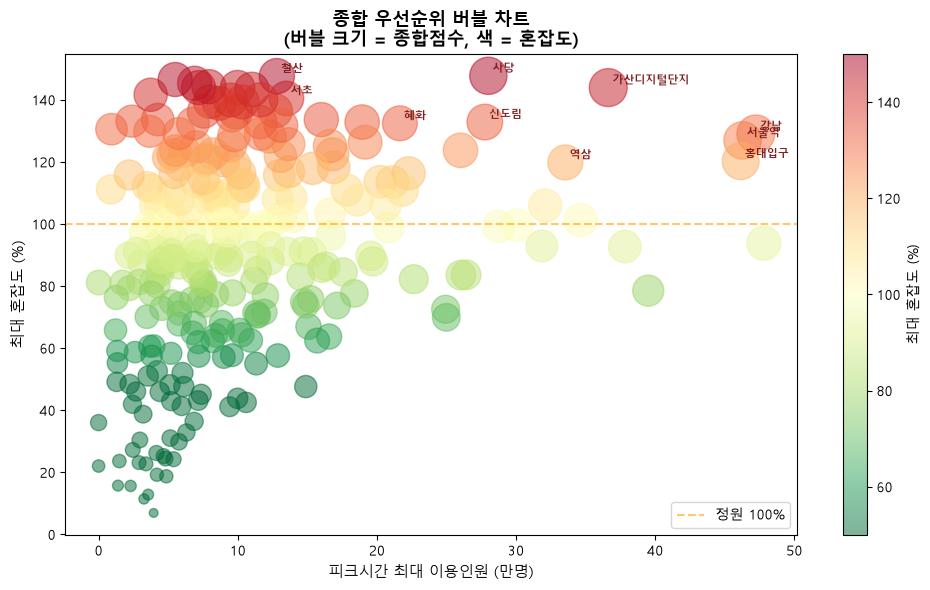

In [ ]:
# ── 3-QA. 시각화: 종합 우선순위 버블 차트 ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

peak_max = df_priority[['피크_출근','피크_퇴근']].max(axis=1)
sc = ax.scatter(
    peak_max / 1e4,
    df_priority['혼잡_최대'],
    s=df_priority['종합점수'] * 800 + 20,
    alpha=0.5,
    c=df_priority['혼잡_최대'],
    cmap='RdYlGn_r',
    vmin=50, vmax=150
)
plt.colorbar(sc, ax=ax, label='최대 혼잡도 (%)')

# TOP 10 레이블
for _, row in top10_priority.iterrows():
    peak_v = max(row['피크_출근'], row['피크_퇴근'])
    ax.annotate(f"{row['지하철역']}",
                xy=(peak_v/1e4, row['혼잡_최대']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=8, fontweight='bold', color='#7F1D1D')

ax.axhline(y=100, color='orange', linestyle='--', alpha=0.6, label='정원 100%')
ax.set_xlabel('피크시간 최대 이용인원 (만명)', fontsize=11)
ax.set_ylabel('최대 혼잡도 (%)', fontsize=11)
ax.set_title('종합 우선순위 버블 차트\n(버블 크기 = 종합점수, 색 = 혼잡도)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_priority_bubble.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 결론 요약

In [ ]:
# ── 4. 최종 요약 출력 ────────────────────────────────────────────────
# YoY
d25 = df_ride[df_ride['사용월'].between(202501, 202505)]['월총이용'].sum()
d26 = df_ride[df_ride['사용월'].between(202601, 202605)]['월총이용'].sum()
yoy = (d26 - d25) / d25 * 100

# 최고 혼잡도
max_cong_row = cong_weekday.loc[cong_weekday['혼잡_최대'].idxmax()]

print('=' * 60)
print('★ SCQA 핵심 수치 요약 ★')
print('=' * 60)
print(f'[S] 2026 1~5월 이용 YoY : {yoy:+.1f}%')
print(f'[S] 2026-05 분석 역 수  : {len(df_ride_2605["지하철역"].unique()):,}역')
print(f'[C] 혼잡도 100% 초과 구간: {(cong_weekday["혼잡_최대"] >= 100).sum()}개')
print(f'[C] 최고 혼잡도          : {max_cong_row["혼잡_최대"]:.1f}% '
      f'({max_cong_row["호선"]} {max_cong_row["출발역"]} {max_cong_row["상하구분"]})')
print(f'[Q] 핵심 질문: 피크시간 방향·구간 기준 어디부터 무엇을?')
print()
print('[A] 우선 개선 TOP 5')
improvements = [
    ('1', '2호선 사당 외선', '08:00~09:00', '147.7%', '외선 증회 + 칸별 분산'),
    ('2', '7호선 철산 상선', '07:30~08:30', '147.6%', '배차 간격 축소'),
    ('3', '8호선 하선 (몽촌토성~천호)', '07:30~08:30', '146.5%', '구간 증회 + 예비열차'),
    ('4', '2호선 방배·서초 내선', '18:00~19:00', '143.9%', '퇴근 증회 + 시차출퇴근'),
    ('5', '7호선 군자권 하선', '07:30~08:30', '144.2%', '환승 동선 분리'),
]
for r, loc, time, cong, action in improvements:
    print(f'  #{r} {loc:25s} {time} | {cong} | {action}')
print('=' * 60)

★ SCQA 핵심 수치 요약 ★
[S] 2026 1~5월 이용 YoY : +25.4%
[S] 2026-05 분석 역 수  : 528역
[C] 혼잡도 100% 초과 구간: 166개
[C] 최고 혼잡도          : 147.7% (2호선 사당 외선)
[Q] 핵심 질문: 피크시간 방향·구간 기준 어디부터 무엇을?

[A] 우선 개선 TOP 5
  #1 2호선 사당 외선                 08:00~09:00 | 147.7% | 외선 증회 + 칸별 분산
  #2 7호선 철산 상선                 07:30~08:30 | 147.6% | 배차 간격 축소
  #3 8호선 하선 (몽촌토성~천호)          07:30~08:30 | 146.5% | 구간 증회 + 예비열차
  #4 2호선 방배·서초 내선              18:00~19:00 | 143.9% | 퇴근 증회 + 시차출퇴근
  #5 7호선 군자권 하선                07:30~08:30 | 144.2% | 환승 동선 분리


In [ ]:
# ── 4. 최종 결과물 저장 (분석 결과 CSV) ──────────────────────────────
output_path = BASE

# JOIN 결과 저장
df_joined2.to_csv(os.path.join(output_path, 'result_joined_ride_congestion.csv'),
                   index=False, encoding='utf-8-sig')

# 우선순위 저장
top10_priority.to_csv(os.path.join(output_path, 'result_top10_priority.csv'),
                       encoding='utf-8-sig')

print('저장 완료:')
print(f'  - result_joined_ride_congestion.csv ({len(df_joined2):,}행)')
print(f'  - result_top10_priority.csv (10행)')

저장 완료:
  - result_joined_ride_congestion.csv (622행)
  - result_top10_priority.csv (10행)
